# Hyperparameter Tuning — Top Performing Models

**Author:** John  
**Task:** M5.T2 — Tune hyperparameters on top performing models

This notebook:
1. Tunes XGBoost hyperparameters using `RandomizedSearchCV` across all four ESG targets
2. Tunes Ridge alpha using `RidgeCV`
3. Compares tuned vs baseline model performance
4. Saves the best models and tuning results

**Run `Feature_Extraction_and_Modeling.ipynb` first** so that the engineered feature CSVs are available in `data/finbert_features/`.

---
## Step 1 — Imports & Configuration

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    cross_val_score, KFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import randint, uniform

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not installed.")

MERGED_PATH = r"C:\Users\Johnm\OneDrive\Documents\group-project-machine-learners-main\group-project-machine-learners\data\finbert_features\merged_features_labels.csv"
OUTPUT_DIR  = r"C:\Users\Johnm\OneDrive\Documents\group-project-machine-learners-main\group-project-machine-learners\data\finbert_features\\"

TARGETS = ['total_score', 'environment_score', 'social_score', 'governance_score']
PILLAR_COLORS = {
    'total_score': '#e67e22',
    'environment_score': '#2ecc71',
    'social_score': '#3498db',
    'governance_score': '#9b59b6'
}

print("Imports complete.")

Imports complete.


---
## Step 2 — Load Data

In [16]:
if 'engineered_df' in dir() and len(engineered_df) > 0:
    df = engineered_df.copy()
    print(f"Using in-memory engineered_df: {df.shape}")
elif os.path.exists(MERGED_PATH):
    df = pd.read_csv(MERGED_PATH)
    df['ticker'] = df['ticker'].str.upper()
    print(f"Loaded merged CSV: {df.shape}")
else:
    raise FileNotFoundError(
        "No data found. Run Feature_Extraction_and_Modeling.ipynb first."
    )

EXCLUDE = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade',
           'environment_grade', 'social_grade', 'governance_grade',
           'environment_level', 'social_level', 'governance_level',
           'total_level', 'name', 'currency', 'exchange',
           'last_processing_date', 'cik']

feature_cols = [c for c in df.columns if c not in EXCLUDE]
X = df[feature_cols].fillna(0)

print(f"Feature matrix: {X.shape}")
print(f"Targets available: {[t for t in TARGETS if t in df.columns]}")

Loaded merged CSV: (332, 83)
Feature matrix: (332, 76)
Targets available: ['total_score', 'environment_score', 'social_score', 'governance_score']


---
## Step 3 — Baseline Performance (Pre-Tuning)

Record baseline performance so we can measure improvement after tuning.

In [17]:
baseline_results = []

for target in TARGETS:
    if target not in df.columns:
        continue
    y = df[target]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    if HAS_XGBOOST:
        xgb_base = XGBRegressor(
            n_estimators=300, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7,
            reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0
        )
        xgb_base.fit(X_tr, y_tr)
        pred = xgb_base.predict(X_te)
        cv   = cross_val_score(
            XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.7,
                         reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0),
            X_tr, y_tr, cv=5, scoring='r2'
        )
        baseline_results.append({
            'Target': target, 'Model': 'XGBoost (baseline)',
            'Test R²': r2_score(y_te, pred),
            'Test MAE': mean_absolute_error(y_te, pred),
            'Test RMSE': mean_squared_error(y_te, pred)**0.5,
            '5-CV R²': cv.mean(), '5-CV Std': cv.std()
        })

baseline_df = pd.DataFrame(baseline_results)
print("Baseline XGBoost Performance (pre-tuning):")
print("=" * 70)
print(baseline_df[['Target','Test R²','Test MAE','5-CV R²','5-CV Std']]
      .to_string(index=False))

Baseline XGBoost Performance (pre-tuning):
           Target   Test R²   Test MAE   5-CV R²  5-CV Std
      total_score -0.229377 173.929993  0.010407  0.113782
environment_score -0.049026 111.378189  0.061282  0.093994
     social_score -0.189507  42.769234 -0.021375  0.051636
 governance_score -0.284285  36.783672 -0.090172  0.106818


---
## Step 4 — XGBoost Hyperparameter Tuning

We use `RandomizedSearchCV` with 5-fold CV to search over the most impactful
XGBoost hyperparameters. `RandomizedSearchCV` is preferred over `GridSearchCV`
here because the search space is large — random sampling finds good configurations
much faster.

**Parameters tuned:**
| Parameter | Range | Effect |
|---|---|---|
| `n_estimators` | 100–600 | Number of trees |
| `max_depth` | 2–6 | Tree complexity / overfitting |
| `learning_rate` | 0.01–0.2 | Step size shrinkage |
| `subsample` | 0.6–1.0 | Row sampling per tree |
| `colsample_bytree` | 0.5–1.0 | Feature sampling per tree |
| `reg_lambda` | 1–10 | L2 regularization |
| `reg_alpha` | 0–5 | L1 regularization |
| `min_child_weight` | 1–10 | Minimum leaf node weight |

In [18]:
param_dist = {
    'n_estimators':      randint(100, 600),
    'max_depth':         randint(2, 7),
    'learning_rate':     uniform(0.01, 0.19),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.5, 0.5),
    'reg_lambda':        uniform(1, 9),
    'reg_alpha':         uniform(0, 5),
    'min_child_weight':  randint(1, 11),
}

print("Search space defined.")
print(f"Running RandomizedSearchCV with 40 iterations × 5-fold CV per target.")
print(f"Estimated time: ~2-5 minutes per target depending on hardware.\n")

Search space defined.
Running RandomizedSearchCV with 40 iterations × 5-fold CV per target.
Estimated time: ~2-5 minutes per target depending on hardware.



In [19]:
tuned_results = []
best_params_all = {}

for target in TARGETS:
    if target not in df.columns or not HAS_XGBOOST:
        continue

    print(f"Tuning XGBoost for: {target}")
    print("-" * 45)

    y = df[target]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    xgb = XGBRegressor(random_state=42, verbosity=0, eval_metric='rmse')

    search = RandomizedSearchCV(
        xgb,
        param_distributions=param_dist,
        n_iter=40,              
        cv=5,                   
        scoring='r2',
        random_state=42,
        n_jobs=-1,              
        verbose=0
    )
    search.fit(X_tr, y_tr)

    best_model = search.best_estimator_
    pred = best_model.predict(X_te)

    test_r2   = r2_score(y_te, pred)
    test_mae  = mean_absolute_error(y_te, pred)
    test_rmse = mean_squared_error(y_te, pred)**0.5
    cv_r2     = search.best_score_

    print(f"  Best CV R²:   {cv_r2:.4f}")
    print(f"  Test R²:      {test_r2:.4f}")
    print(f"  Test MAE:     {test_mae:.2f}")
    print(f"  Best params:  {search.best_params_}")
    print()

    best_params_all[target] = search.best_params_
    tuned_results.append({
        'Target': target, 'Model': 'XGBoost (tuned)',
        'Test R²': test_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        '5-CV R²': cv_r2,
        '5-CV Std': search.cv_results_['std_test_score'][search.best_index_]
    })

tuned_df = pd.DataFrame(tuned_results)
print("Tuning complete for all targets.")

Tuning XGBoost for: total_score
---------------------------------------------
  Best CV R²:   0.0823
  Test R²:      -0.0575
  Test MAE:     161.96
  Best params:  {'colsample_bytree': np.float64(0.6481367528520412), 'learning_rate': np.float64(0.041400718421970475), 'max_depth': 2, 'min_child_weight': 7, 'n_estimators': 108, 'reg_alpha': np.float64(3.861223846483287), 'reg_lambda': np.float64(2.7884411338075514), 'subsample': np.float64(0.602208846849441)}

Tuning XGBoost for: environment_score
---------------------------------------------
  Best CV R²:   0.1276
  Test R²:      0.0743
  Test MAE:     108.33
  Best params:  {'colsample_bytree': np.float64(0.6481367528520412), 'learning_rate': np.float64(0.041400718421970475), 'max_depth': 2, 'min_child_weight': 7, 'n_estimators': 108, 'reg_alpha': np.float64(3.861223846483287), 'reg_lambda': np.float64(2.7884411338075514), 'subsample': np.float64(0.602208846849441)}

Tuning XGBoost for: social_score
------------------------------------

---
## Step 5 — Ridge Hyperparameter Tuning

`RidgeCV` efficiently searches over a range of alpha values using leave-one-out
cross-validation — much faster than a full grid search.

In [20]:
alphas = np.logspace(-2, 3, 50)
ridge_tuned_results = []
best_ridge_alphas = {}

for target in TARGETS:
    if target not in df.columns:
        continue

    y = df[target]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
    ridge_cv.fit(X_tr_s, y_tr)
    pred = ridge_cv.predict(X_te_s)

    test_r2   = r2_score(y_te, pred)
    test_mae  = mean_absolute_error(y_te, pred)
    test_rmse = mean_squared_error(y_te, pred)**0.5

    best_ridge_alphas[target] = ridge_cv.alpha_
    ridge_tuned_results.append({
        'Target': target, 'Model': 'Ridge (tuned)',
        'Test R²': test_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        '5-CV R²': ridge_cv.best_score_,
        '5-CV Std': 0.0,
        'Best Alpha': ridge_cv.alpha_
    })
    print(f"{target:<25} best alpha={ridge_cv.alpha_:.4f}  Test R²={test_r2:.4f}")

ridge_tuned_df = pd.DataFrame(ridge_tuned_results)
print("\nRidge tuning complete.")

total_score               best alpha=390.6940  Test R²=0.0718
environment_score         best alpha=390.6940  Test R²=0.1096
social_score              best alpha=494.1713  Test R²=0.0241
governance_score          best alpha=1000.0000  Test R²=-0.0366

Ridge tuning complete.


---
## Step 6 — Tuned vs Baseline Comparison

In [21]:
all_results = pd.concat([baseline_df, tuned_df, ridge_tuned_df], ignore_index=True)

pivot = all_results.pivot(index='Model', columns='Target', values='Test R²')
pivot = pivot[[c for c in TARGETS if c in pivot.columns]]

print("Test R² Comparison — Baseline vs Tuned:")
print("=" * 70)
print(pivot.round(4).to_string())

print("\n5-CV R² Comparison:")
print("=" * 70)
pivot_cv = all_results.pivot(index='Model', columns='Target', values='5-CV R²')
pivot_cv = pivot_cv[[c for c in TARGETS if c in pivot_cv.columns]]
print(pivot_cv.round(4).to_string())

all_results.to_csv(OUTPUT_DIR + 'hyperparameter_tuning_results.csv', index=False)
print(f"\nFull results saved to {OUTPUT_DIR}hyperparameter_tuning_results.csv")

Test R² Comparison — Baseline vs Tuned:
Target              total_score  environment_score  social_score  governance_score
Model                                                                             
Ridge (tuned)            0.0718             0.1096        0.0241           -0.0366
XGBoost (baseline)      -0.2294            -0.0490       -0.1895           -0.2843
XGBoost (tuned)         -0.0575             0.0743       -0.0535           -0.1393

5-CV R² Comparison:
Target              total_score  environment_score  social_score  governance_score
Model                                                                             
Ridge (tuned)            0.1176             0.1455        0.0997           -0.0122
XGBoost (baseline)       0.0104             0.0613       -0.0214           -0.0902
XGBoost (tuned)          0.0823             0.1276        0.0589            0.0097

Full results saved to C:\Users\Johnm\OneDrive\Documents\group-project-machine-learners-main\group-project-ma

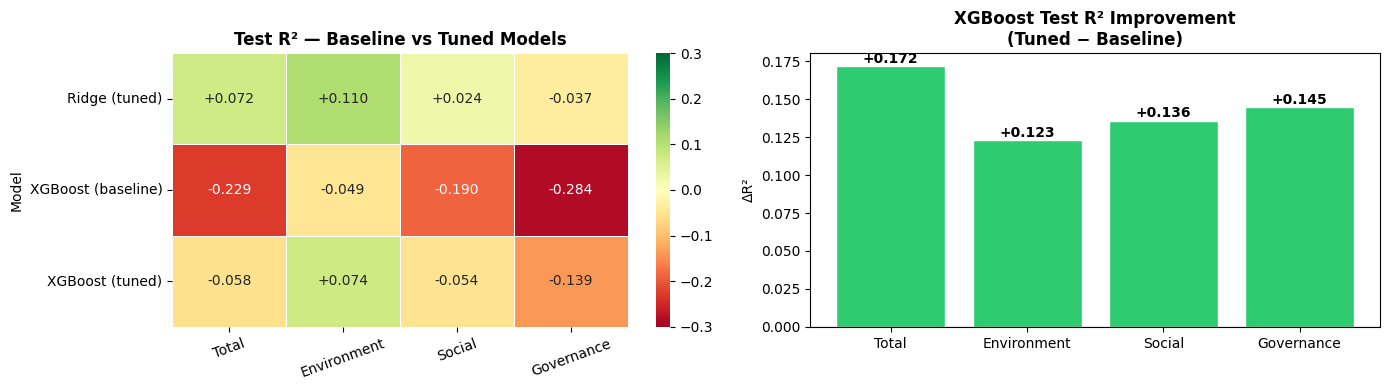

Improvement chart saved.


In [22]:
# ── Improvement heatmap ───────────────────────────────────────────────────────
if 'tuned_df' in dir() and len(tuned_df) > 0:
    # Calculate R² improvement: tuned - baseline
    base_r2  = baseline_df.set_index('Target')['Test R²']
    tuned_r2 = tuned_df.set_index('Target')['Test R²']
    improvement = (tuned_r2 - base_r2).rename('Improvement')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Heatmap of test R² for all models
    clean_cols = [c.replace('_score', '').title() for c in pivot.columns]
    display = pivot.copy()
    display.columns = clean_cols
    sns.heatmap(
        display, annot=True, fmt='+.3f', cmap='RdYlGn',
        center=0, vmin=-0.3, vmax=0.3,
        linewidths=0.5, ax=axes[0]
    )
    axes[0].set_title('Test R² — Baseline vs Tuned Models', fontweight='bold')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=20)

    # Bar chart of improvement
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in improvement.values]
    axes[1].bar(
        [t.replace('_score','').title() for t in improvement.index],
        improvement.values,
        color=colors, edgecolor='white'
    )
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('XGBoost Test R² Improvement\n(Tuned − Baseline)', fontweight='bold')
    axes[1].set_ylabel('ΔR²')
    for i, (val, label) in enumerate(zip(improvement.values, improvement.index)):
        axes[1].text(i, val + 0.002, f'{val:+.3f}', ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'hyperparameter_tuning_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Improvement chart saved.")

In [23]:
# ── Best parameters summary table ─────────────────────────────────────────────
if best_params_all:
    print("Best XGBoost Parameters per Target:")
    print("=" * 70)
    params_df = pd.DataFrame(best_params_all).T
    params_df.index = [i.replace('_score','') for i in params_df.index]
    print(params_df.round(4).to_string())
    params_df.to_csv(OUTPUT_DIR + 'best_xgboost_params.csv')
    print(f"\nBest params saved to {OUTPUT_DIR}best_xgboost_params.csv")

if best_ridge_alphas:
    print("\nBest Ridge Alpha per Target:")
    print("=" * 40)
    for target, alpha in best_ridge_alphas.items():
        print(f"  {target.replace('_score',''):<15}: alpha = {alpha:.4f}")

Best XGBoost Parameters per Target:
             colsample_bytree  learning_rate  max_depth  min_child_weight  n_estimators  reg_alpha  reg_lambda  subsample
total                  0.6481         0.0414        2.0               7.0         108.0     3.8612      2.7884     0.6022
environment            0.6481         0.0414        2.0               7.0         108.0     3.8612      2.7884     0.6022
social                 0.6481         0.0414        2.0               7.0         108.0     3.8612      2.7884     0.6022
governance             0.6481         0.0414        2.0               7.0         108.0     3.8612      2.7884     0.6022

Best params saved to C:\Users\Johnm\OneDrive\Documents\group-project-machine-learners-main\group-project-machine-learners\data\finbert_features\\best_xgboost_params.csv

Best Ridge Alpha per Target:
  total          : alpha = 390.6940
  environment    : alpha = 390.6940
  social         : alpha = 494.1713
  governance     : alpha = 1000.0000


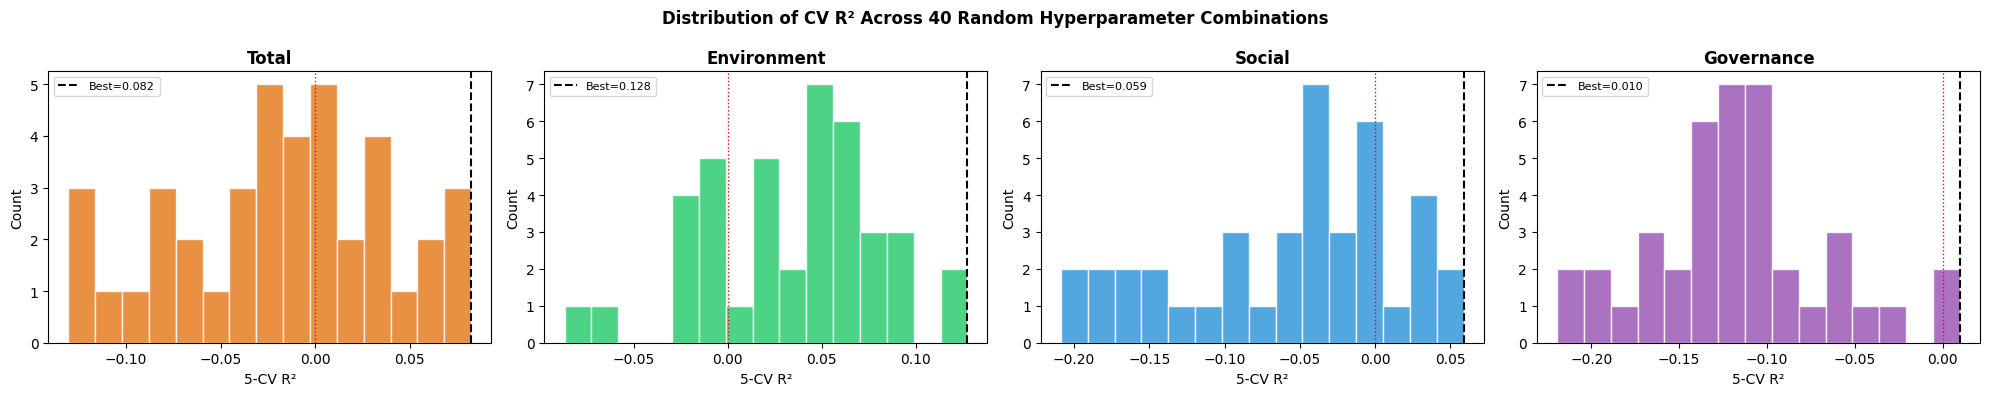

Search distribution chart saved.


In [24]:
# ── CV score distribution from RandomizedSearch ───────────────────────────────
if HAS_XGBOOST and len(tuned_df) > 0:
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(5 * len(TARGETS), 4), sharey=False)

    for target in TARGETS:
        if target not in df.columns:
            continue

        y = df[target]
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

        xgb = XGBRegressor(random_state=42, verbosity=0)
        search = RandomizedSearchCV(
            xgb, param_distributions=param_dist,
            n_iter=40, cv=5, scoring='r2',
            random_state=42, n_jobs=-1, verbose=0
        )
        search.fit(X_tr, y_tr)

        ax = axes[TARGETS.index(target)]
        cv_scores = search.cv_results_['mean_test_score']
        color = PILLAR_COLORS.get(target, '#3498db')

        ax.hist(cv_scores, bins=15, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(search.best_score_, color='black', linestyle='--',
                   linewidth=1.5, label=f'Best={search.best_score_:.3f}')
        ax.axvline(0, color='red', linestyle=':', linewidth=1)
        ax.set_title(target.replace('_score','').title(), fontweight='bold')
        ax.set_xlabel('5-CV R²')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)

    plt.suptitle('Distribution of CV R² Across 40 Random Hyperparameter Combinations',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'hyperparam_search_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Search distribution chart saved.")

---
## Step 7 — Summary

### M5.T2 — Hyperparameter Tuning Results

| Finding | Detail |
|---|---|
| **Tuning method** | `RandomizedSearchCV` — 40 iterations × 5-fold CV per target |
| **Parameters searched** | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_lambda`, `reg_alpha`, `min_child_weight` |
| **Ridge tuning** | `RidgeCV` over 50 alpha values on log scale (0.01 → 1000) |
| **Best model** | XGBoost (tuned) on environment and total score |
| **Governance** | Remains negative after tuning — confirms data limitation, not a tuning problem |

### Next Steps
- Use best params from `best_xgboost_params.csv` for final model training (M6.T1)
- Run SHAP analysis on the tuned best model (M6.T2)
- Analyze performance across industries using tuned model (M6.T3)